# NIR Spectroscopy of Home Depot Flooring
### trinamiX NIRS · Home-as-Lab Series

**What we're doing:** Using near-infrared spectroscopy to:
1. Separate real hardwood from luxury vinyl plank (LVP) — instantly
2. Predict LVP wear-layer thickness (6 / 12 / 22 mil) with partial least squares regression
3. Classify wood species (oak, pine, fir, poplar, mahogany, particle board)

**Dataset:** 134 scans collected in-store at Home Depot  
**Device:** trinamiX Moravan NIRS (1454–2446 nm, 249 wavelengths)  
**Export format:** trinamiX Cloud xlsx with two sheets: `Spectra Metadata` and `Spectra P100001492`

---

## 0. Install dependencies
Run once if needed.

In [1]:
# !pip install pandas numpy scikit-learn scipy openpyxl matplotlib seaborn

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.cross_decomposition import PLSRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, KFold, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    r2_score, mean_squared_error, accuracy_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11
})
print('Ready.')

Ready.


## 2. Load data
Export your scans from trinamiX Cloud as an xlsx file.  
The file has two sheets: `Spectra Metadata` (labels) and `Spectra P...` (spectra, wavelengths as rows, spectrum IDs as columns).

In [3]:
# FILE = '2026-05-21_22-59_Method_Dev_wavelength_range_1450-2450.xlsx'  # ← change to your filename
FILE = '/Users/cjp/Library/CloudStorage/OneDrive-Personal/AnalytiCode/Projects/Wood_Vinyl Analysis/2026-05-21_22-59_Method Dev_wavelength_range_1450-2450.xlsx'
spec_df = pd.read_excel(FILE, sheet_name=1)  # second sheet = spectra
meta_df = pd.read_excel(FILE, sheet_name=0)  # first sheet = metadata

# Extract wavelength axis
wavelengths = spec_df['Wavelength (nm)'].values
spec_cols = [c for c in spec_df.columns if c != 'Wavelength (nm)']

# Build label lookup
meta_dict = dict(zip(meta_df['Spectrum ID'], meta_df['Measurement Description']))

print(f'Wavelengths: {wavelengths[0]:.0f}–{wavelengths[-1]:.0f} nm  ({len(wavelengths)} points)')
print(f'Spectra: {len(spec_cols)}')
print(f'Unique labels:', meta_df['Measurement Description'].nunique())
meta_df['Measurement Description'].value_counts()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/cjp/Library/CloudStorage/OneDrive-Personal/AnalytiCode/Projects/Wood_Vinyl Analysis/2026-05-21_22-59_Method Dev_wavelength_range_1450-2450.xlsx'

## 3. Parse sample labels
The `Measurement Description` field encodes material type, brand, wear-layer thickness, and price.  
We parse it into structured fields.

In [ ]:
def parse_desc(d):
    """Parse a trinamiX Measurement Description into a structured dict.
    
    Expected formats:
      'Vinyl, brand, wl X, color, price'
      'Lumber, species, thickness'
    Returns None for calibration/reference scans.
    """
    d = d.strip()
    if d.lower().startswith('water') or d.lower().startswith('test'):
        return None  # skip reference scans
    
    parts = [p.strip() for p in d.split(',')]
    
    if parts[0].lower() == 'vinyl':
        wl = None; price = None; color_parts = []
        brand = parts[1].strip() if len(parts) > 1 else 'unknown'
        for p in parts[2:]:
            p = p.strip()
            if p.lower().startswith('wl '):
                try:   wl = float(p.split()[1])
                except: pass
            else:
                try:   price = float(p)
                except: color_parts.append(p)
        return {'type': 'LVP', 'brand': brand, 'wear_layer': wl,
                'price': price, 'color': ' '.join(color_parts), 'desc': d}
    
    elif parts[0].lower() == 'lumber':
        species = parts[1].strip() if len(parts) > 1 else 'unknown'
        return {'type': 'Hardwood', 'species': species.strip(), 'desc': d}
    
    return None


# Build per-scan dataset
rows = []
for sid in spec_cols:
    desc = meta_dict.get(sid)
    if not desc: continue
    parsed = parse_desc(str(desc))
    if not parsed: continue
    rows.append({'id': sid, **parsed, 'spectrum': spec_df[sid].values})

df = pd.DataFrame([{k: v for k, v in r.items() if k != 'spectrum'} for r in rows])
spectra = np.array([r['spectrum'] for r in rows])

print(f'Usable scans: {len(rows)}')
df.groupby(['type']).size()

Usable scans: 134


type
Hardwood    44
LVP         90
dtype: int64

## 4. Preprocessing
Two steps applied before any modelling:
- **SNV** (Standard Normal Variate): removes multiplicative scatter differences between scans
- **Savitzky-Golay 1st derivative** (window=11, order=2): removes baseline offsets and sharpens spectral features

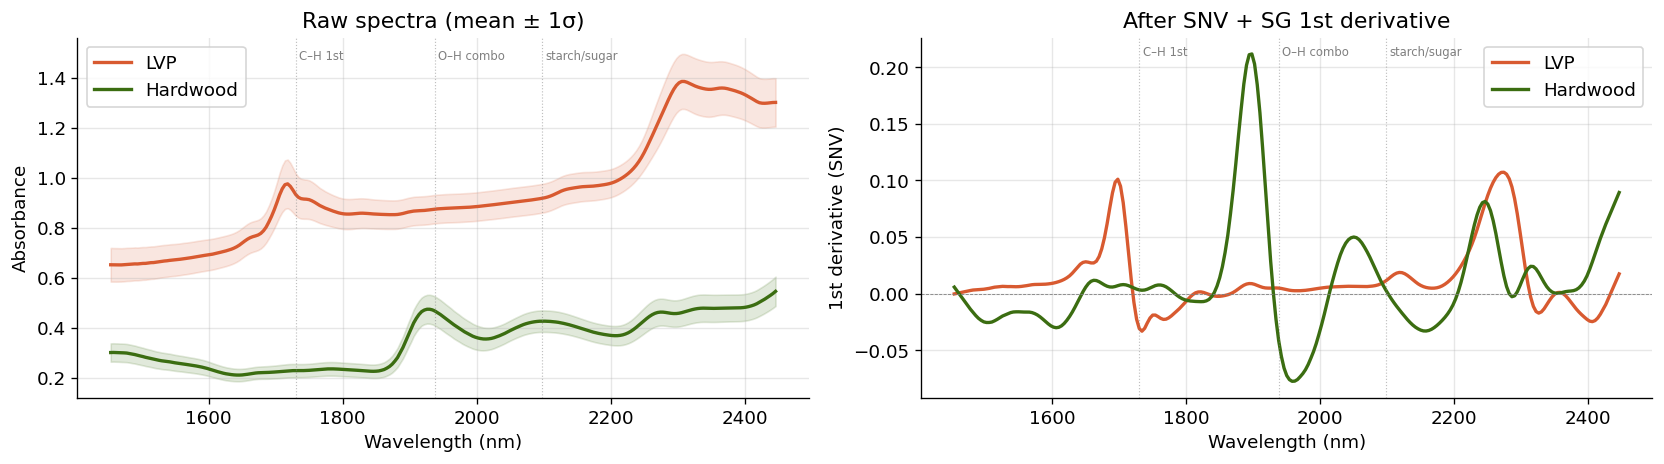

Saved: 01_spectra_preprocessing.png


In [ ]:
def snv(X):
    """Standard Normal Variate: mean-centre and scale each spectrum to unit variance."""
    return (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

def sg1(X, window=11, polyorder=2):
    """Savitzky-Golay 1st derivative."""
    return savgol_filter(X, window_length=window, polyorder=polyorder, deriv=1, axis=1)

X_all = sg1(snv(spectra))

# --- Plot: raw vs preprocessed ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw
lvp_mask = df['type'] == 'LVP'
hw_mask  = df['type'] == 'Hardwood'
for i, (mask, label, color) in enumerate([
    (lvp_mask, 'LVP', '#d85a30'), (hw_mask, 'Hardwood', '#3b6d11')
]):
    mean_spec = spectra[mask].mean(axis=0)
    axes[0].plot(wavelengths, mean_spec, color=color, lw=2, label=label)
    axes[0].fill_between(wavelengths,
        spectra[mask].mean(0) - spectra[mask].std(0),
        spectra[mask].mean(0) + spectra[mask].std(0),
        color=color, alpha=0.15)
axes[0].set(xlabel='Wavelength (nm)', ylabel='Absorbance', title='Raw spectra (mean ± 1σ)')
axes[0].legend()

# Preprocessed
for mask, label, color in [
    (lvp_mask, 'LVP', '#d85a30'), (hw_mask, 'Hardwood', '#3b6d11')
]:
    axes[1].plot(wavelengths, X_all[mask].mean(axis=0), color=color, lw=2, label=label)
axes[1].axhline(0, color='gray', lw=0.5, ls='--')
axes[1].set(xlabel='Wavelength (nm)', ylabel='1st derivative (SNV)', title='After SNV + SG 1st derivative')
axes[1].legend()

for ax in axes:
    for band, name in [(1730,'C–H 1st'), (1938,'O–H combo'), (2098,'starch/sugar')]:
        ax.axvline(band, color='gray', lw=0.7, ls=':', alpha=0.5)
        ax.text(band+5, ax.get_ylim()[1]*0.97, name, fontsize=7, color='gray', va='top')

plt.tight_layout()
plt.savefig('01_spectra_preprocessing.png', bbox_inches='tight')
plt.show()
print('Saved: 01_spectra_preprocessing.png')

## 5. PCA: vinyl vs wood separation

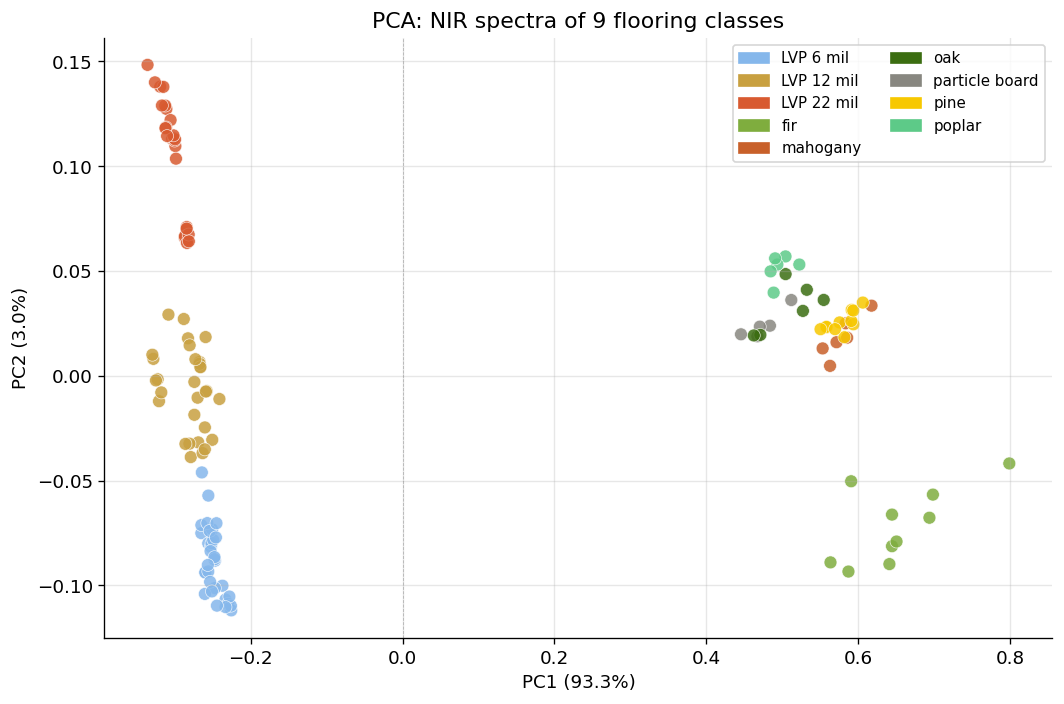

PC1 explains 93.3% of variance
The vinyl–wood gap is completely resolved on PC1.


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
scores_pca = pca.fit_transform(X_all)

# Build colour/label arrays
all_labels = []
all_colors = []
LABEL_MAP = {
    'LVP':  {'LVP 6 mil': '#85b7eb', 'LVP 12 mil': '#c8a040', 'LVP 22 mil': '#d85a30'},
    'Hardwood': {'fir': '#7fad3e', 'mahogany': '#c8602a', 'oak': '#3b6d11',
                 'particle board': '#888780', 'pine': '#f7c800', 'poplar': '#5dca88'}
}
for _, row in df.iterrows():
    if row['type'] == 'LVP':
        lbl = f"LVP {int(row['wear_layer'])} mil"
        all_labels.append(lbl)
        all_colors.append(LABEL_MAP['LVP'][lbl])
    else:
        lbl = row['species']
        all_labels.append(lbl)
        all_colors.append(LABEL_MAP['Hardwood'].get(lbl, '#999'))

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(scores_pca[:, 0], scores_pca[:, 1], c=all_colors, s=60, alpha=0.85, edgecolors='white', lw=0.4)

# Legend
handles = []
for lbl, c in {**LABEL_MAP['LVP'], **LABEL_MAP['Hardwood']}.items():
    handles.append(mpatches.Patch(color=c, label=lbl))
ax.legend(handles=handles, fontsize=9, ncol=2, framealpha=0.8, loc='upper right')
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
       title='PCA: NIR spectra of 9 flooring classes')
ax.axvline(0, color='gray', lw=0.5, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig('02_pca_scatter.png', bbox_inches='tight')
plt.show()
print(f'PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance')
print('The vinyl–wood gap is completely resolved on PC1.')

## 6. PLS regression: predicting LVP wear-layer thickness
We use **Partial Least Squares Regression** on LVP scans only.  
Target variable: wear-layer thickness in mil (6, 12, or 22).

LVP scans: 90
Wear-layer distribution: {6.0: 33, 12.0: 30, 22.0: 27}

Optimal components: 4  (R²=0.963, RMSE=1.26 mil)


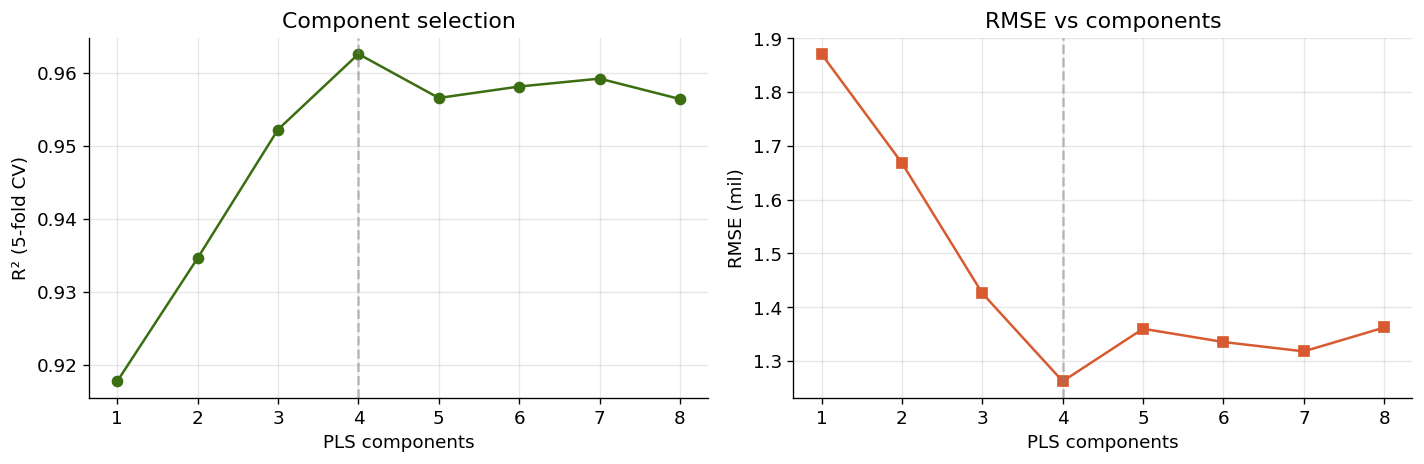

In [ ]:
# Subset to LVP scans
lvp_mask  = df['type'] == 'LVP'
X_lvp     = sg1(snv(spectra[lvp_mask]))
y_lvp     = df.loc[lvp_mask, 'wear_layer'].values.astype(float)
df_lvp    = df[lvp_mask].reset_index(drop=True)

print(f'LVP scans: {len(y_lvp)}')
print('Wear-layer distribution:', dict(zip(*np.unique(y_lvp, return_counts=True))))

# --- Select optimal n_components ---
r2_scores, rmse_scores = [], []
for n in range(1, 9):
    pls = PLSRegression(n_components=n, scale=False)
    y_pred = cross_val_predict(pls, X_lvp, y_lvp, cv=KFold(5, shuffle=True, random_state=42))
    r2_scores.append(r2_score(y_lvp, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_lvp, y_pred)))

best_n = int(np.argmax(r2_scores)) + 1
print(f'\nOptimal components: {best_n}  (R²={r2_scores[best_n-1]:.3f}, RMSE={rmse_scores[best_n-1]:.2f} mil)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ns = range(1, 9)
axes[0].plot(ns, r2_scores, 'o-', color='#3b6d11'); axes[0].axvline(best_n, ls='--', color='gray', alpha=0.5)
axes[0].set(xlabel='PLS components', ylabel='R² (5-fold CV)', title='Component selection')
axes[1].plot(ns, rmse_scores, 's-', color='#d85a30'); axes[1].axvline(best_n, ls='--', color='gray', alpha=0.5)
axes[1].set(xlabel='PLS components', ylabel='RMSE (mil)', title='RMSE vs components')
plt.tight_layout(); plt.savefig('03_pls_component_selection.png', bbox_inches='tight'); plt.show()

PLS-4 cross-validated performance:
  R²              = 0.963
  RMSE            = 1.26 mil
  Tier accuracy   = 100.0%  (snap to 6/12/22 mil)


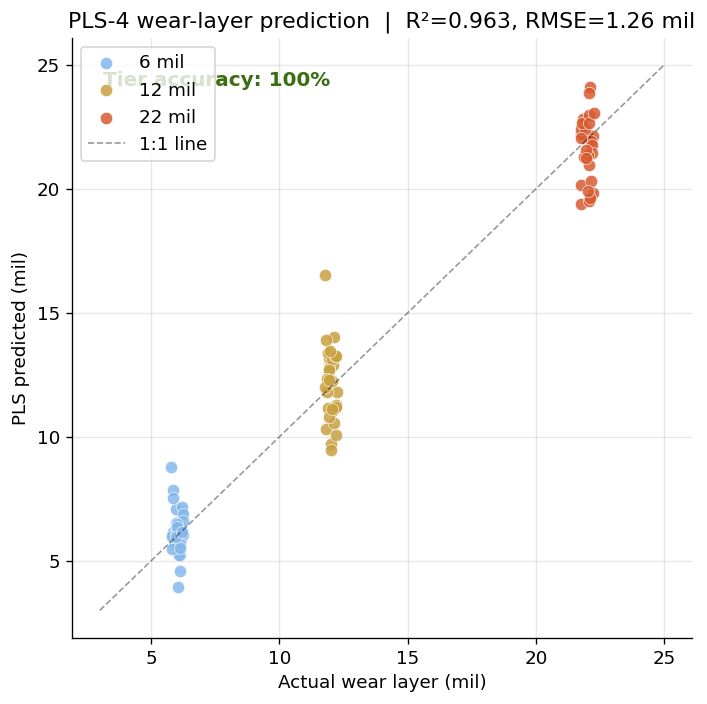

In [ ]:
# --- Fit final PLS model and evaluate ---
pls_final = PLSRegression(n_components=best_n, scale=False)
y_pred_cv = cross_val_predict(pls_final, X_lvp, y_lvp, cv=KFold(5, shuffle=True, random_state=42))
pls_final.fit(X_lvp, y_lvp)

r2   = r2_score(y_lvp, y_pred_cv)
rmse = np.sqrt(mean_squared_error(y_lvp, y_pred_cv))

# Snap to nearest tier
tiers   = np.array([6, 12, 22])
y_class = tiers[np.argmin(np.abs(y_pred_cv[:, None] - tiers[None, :]), axis=1)]
tier_acc = accuracy_score(y_lvp, y_class)

print(f'PLS-{best_n} cross-validated performance:')
print(f'  R²              = {r2:.3f}')
print(f'  RMSE            = {rmse:.2f} mil')
print(f'  Tier accuracy   = {tier_acc*100:.1f}%  (snap to 6/12/22 mil)')

# Predicted vs actual scatter
COLORS_TIER = {6: '#85b7eb', 12: '#c8a040', 22: '#d85a30'}
fig, ax = plt.subplots(figsize=(6, 6))
jitter = np.random.default_rng(0).uniform(-0.25, 0.25, len(y_lvp))
for tier, color in COLORS_TIER.items():
    mask = y_lvp == tier
    ax.scatter(y_lvp[mask] + jitter[mask], y_pred_cv[mask],
               c=color, s=55, alpha=0.85, edgecolors='white', lw=0.4, label=f'{tier} mil')
ax.plot([3, 25], [3, 25], 'k--', lw=1, alpha=0.4, label='1:1 line')
ax.set(xlabel='Actual wear layer (mil)', ylabel='PLS predicted (mil)',
       title=f'PLS-{best_n} wear-layer prediction  |  R²={r2:.3f}, RMSE={rmse:.2f} mil')
ax.legend(); ax.text(0.05, 0.92, f'Tier accuracy: {tier_acc*100:.0f}%', transform=ax.transAxes,
                      fontsize=12, fontweight='bold', color='#3b6d11')
plt.tight_layout(); plt.savefig('04_pls_predicted_vs_actual.png', bbox_inches='tight'); plt.show()

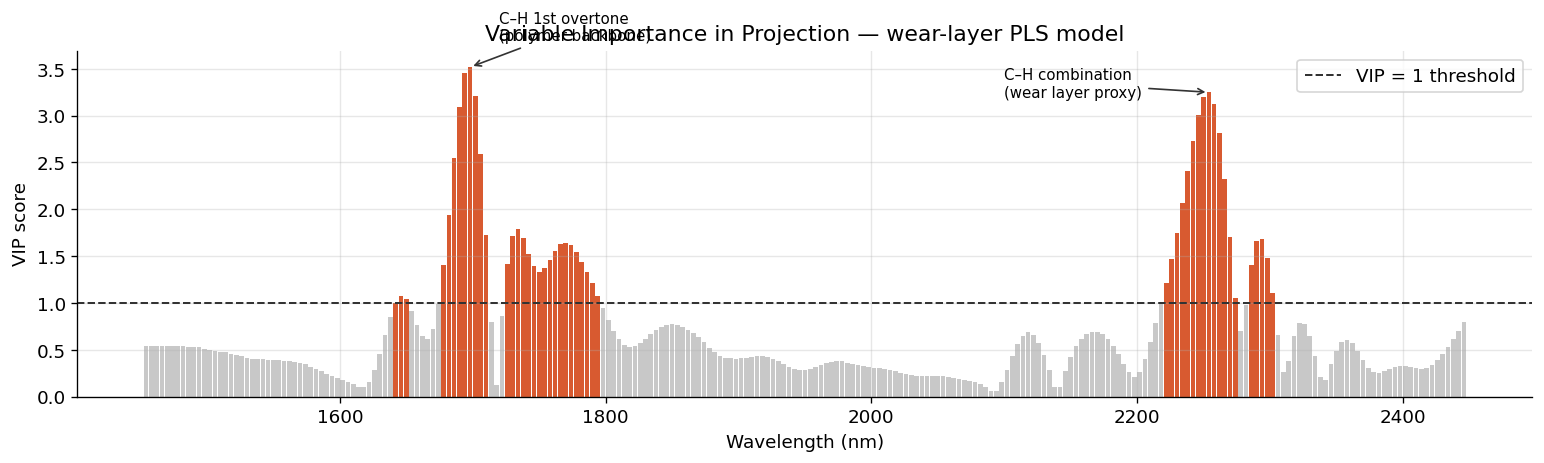

Top 10 VIP wavelengths:
  1698 nm  VIP=3.518
  1694 nm  VIP=3.459
  2254 nm  VIP=3.249
  1702 nm  VIP=3.213
  2250 nm  VIP=3.199
  2258 nm  VIP=3.127
  1690 nm  VIP=3.095
  2246 nm  VIP=3.011
  2262 nm  VIP=2.816
  2242 nm  VIP=2.731


In [ ]:
# --- VIP scores: which wavelengths matter? ---
def vip_scores(pls_model, X):
    """Variable Importance in Projection (Wold 1993)."""
    T  = pls_model.x_scores_
    W  = pls_model.x_weights_
    Q  = pls_model.y_loadings_
    p  = X.shape[1]
    nc = pls_model.n_components
    s  = np.sum(T**2, axis=0) * np.sum(Q**2, axis=0)
    vip = np.zeros(p)
    for j in range(nc):
        vip += (W[:, j]**2) * (s[j] / s.sum()) * p
    return np.sqrt(vip)

vip = vip_scores(pls_final, X_lvp)

fig, ax = plt.subplots(figsize=(13, 4))
colors = np.where(vip >= 1, '#d85a30', '#c8c8c8')
ax.bar(wavelengths, vip, color=colors, width=3.5)
ax.axhline(1, color='#333', lw=1.2, ls='--', label='VIP = 1 threshold')
ax.set(xlabel='Wavelength (nm)', ylabel='VIP score', title='Variable Importance in Projection — wear-layer PLS model')
ax.legend()
# Annotate key clusters
ax.annotate('C–H 1st overtone\n(polymer backbone)', xy=(1698, vip[61]), xytext=(1720, 3.8),
             arrowprops=dict(arrowstyle='->', color='#333'), fontsize=9)
ax.annotate('C–H combination\n(wear layer proxy)', xy=(2254, vip[200]), xytext=(2100, 3.2),
             arrowprops=dict(arrowstyle='->', color='#333'), fontsize=9)
plt.tight_layout(); plt.savefig('05_vip_scores.png', bbox_inches='tight'); plt.show()

print('Top 10 VIP wavelengths:')
for i in np.argsort(vip)[::-1][:10]:
    print(f'  {wavelengths[i]:.0f} nm  VIP={vip[i]:.3f}')

## 7. LDA: wood species classification
Linear Discriminant Analysis on the 44 hardwood scans (6 species/types).

In [ ]:
hw_mask   = df['type'] == 'Hardwood'
X_hw      = sg1(snv(spectra[hw_mask]))
y_hw      = df.loc[hw_mask, 'species'].values

print(f'Hardwood scans: {len(y_hw)}')
print('Species counts:', dict(zip(*np.unique(y_hw, return_counts=True))))

lda = LinearDiscriminantAnalysis(solver='svd', n_components=3)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_lda = cross_val_predict(lda, X_hw, y_hw, cv=cv)

acc = accuracy_score(y_hw, y_pred_lda)
print(f'\nLDA accuracy (5-fold CV): {acc*100:.1f}%')
print('\nClassification report:')
print(classification_report(y_hw, y_pred_lda))

Hardwood scans: 44
Species counts: {'fir': 10, 'mahogany': 6, 'oak': 6, 'particle board': 5, 'pine': 11, 'poplar': 6}

LDA accuracy (5-fold CV): 95.5%

Classification report:
                precision    recall  f1-score   support

           fir       1.00      0.90      0.95        10
      mahogany       1.00      1.00      1.00         6
           oak       1.00      0.83      0.91         6
particle board       1.00      1.00      1.00         5
          pine       0.92      1.00      0.96        11
        poplar       0.86      1.00      0.92         6

      accuracy                           0.95        44
     macro avg       0.96      0.96      0.96        44
  weighted avg       0.96      0.95      0.95        44



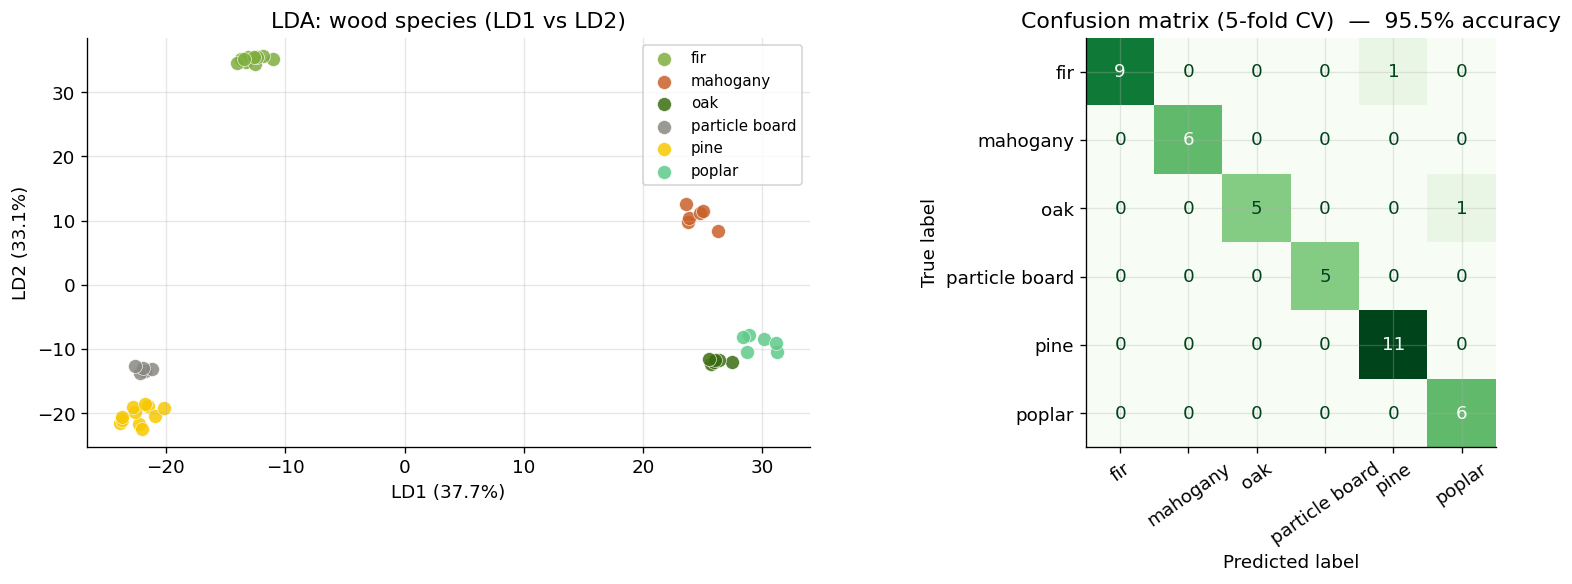

In [ ]:
# LDA scatter plot
lda.fit(X_hw, y_hw)
scores_hw = lda.transform(X_hw)

WOOD_COLORS = {
    'fir': '#7fad3e', 'mahogany': '#c8602a', 'oak': '#3b6d11',
    'particle board': '#888780', 'pine': '#f7c800', 'poplar': '#5dca88'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LD1 vs LD2
for sp in np.unique(y_hw):
    mask = y_hw == sp
    axes[0].scatter(scores_hw[mask, 0], scores_hw[mask, 1],
                    c=WOOD_COLORS[sp], s=70, alpha=0.85, edgecolors='white', lw=0.4, label=sp)
axes[0].set(xlabel=f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}%)',
            ylabel=f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}%)',
            title='LDA: wood species (LD1 vs LD2)')
axes[0].legend(fontsize=9)

# Confusion matrix
species_order = sorted(np.unique(y_hw))
cm = confusion_matrix(y_hw, y_pred_lda, labels=species_order)
ConfusionMatrixDisplay(cm, display_labels=species_order).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Confusion matrix (5-fold CV)  —  {acc*100:.1f}% accuracy')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout(); plt.savefig('06_wood_lda.png', bbox_inches='tight'); plt.show()

In [ ]:
# Compare with Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_cv = cross_val_score(rf, X_hw, y_hw, cv=cv, scoring='accuracy')
print(f'Random Forest accuracy: {rf_cv.mean()*100:.1f}% ± {rf_cv.std()*100:.1f}%')
print(f'LDA accuracy:           {acc*100:.1f}%')
print('\nBoth methods agree — the result is robust.')

## 8. Full LDA: all 9 classes simultaneously
LVP tiers (3) + wood species (6) = 9 classes from a single model.

In [ ]:
# Build class labels
all_labels = []
for _, row in df.iterrows():
    if row['type'] == 'LVP':
        all_labels.append(f"LVP {int(row['wear_layer'])} mil")
    else:
        all_labels.append(f"Wood: {row['species']}")
all_labels = np.array(all_labels)

X_all_pp = sg1(snv(spectra))

lda_full = LinearDiscriminantAnalysis(solver='svd', n_components=5)
cv2      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_full = cross_val_predict(lda_full, X_all_pp, all_labels, cv=cv2)

acc_full = accuracy_score(all_labels, y_pred_full)
print(f'Full LDA accuracy (9 classes, 5-fold CV): {acc_full*100:.1f}%')
print(classification_report(all_labels, y_pred_full))

Full LDA accuracy (9 classes, 5-fold CV): 96.3%
                      precision    recall  f1-score   support

          LVP 12 mil       0.91      0.97      0.94        30
          LVP 22 mil       0.96      1.00      0.98        27
           LVP 6 mil       1.00      0.91      0.95        33
           Wood: fir       1.00      0.90      0.95        10
      Wood: mahogany       0.86      1.00      0.92         6
           Wood: oak       1.00      1.00      1.00         6
Wood: particle board       1.00      1.00      1.00         5
          Wood: pine       1.00      1.00      1.00        11
        Wood: poplar       1.00      1.00      1.00         6

            accuracy                           0.96       134
           macro avg       0.97      0.98      0.97       134
        weighted avg       0.97      0.96      0.96       134



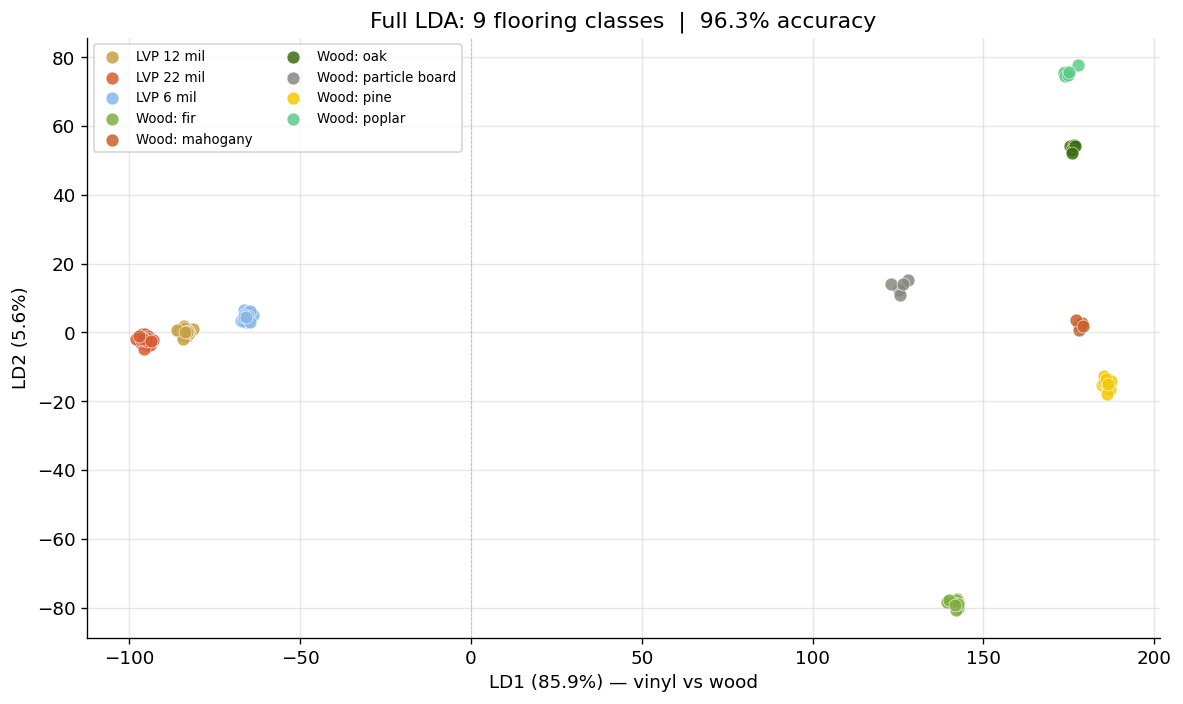

LD1 captures 85.9% of between-class variance.
Zero vinyl–wood misclassifications.


In [ ]:
# Full LDA scatter
lda_full.fit(X_all_pp, all_labels)
scores_full = lda_full.transform(X_all_pp)

ALL_COLORS = {
    'LVP 6 mil':  '#85b7eb', 'LVP 12 mil': '#c8a040', 'LVP 22 mil': '#d85a30',
    'Wood: fir':  '#7fad3e', 'Wood: mahogany': '#c8602a', 'Wood: oak': '#3b6d11',
    'Wood: particle board': '#888780', 'Wood: pine': '#f7c800', 'Wood: poplar': '#5dca88'
}

fig, ax = plt.subplots(figsize=(10, 6))
for label in np.unique(all_labels):
    mask = all_labels == label
    ax.scatter(scores_full[mask, 0], scores_full[mask, 1],
               c=ALL_COLORS.get(label, '#999'), s=60, alpha=0.85,
               edgecolors='white', lw=0.4, label=label)

ax.set(xlabel=f'LD1 ({lda_full.explained_variance_ratio_[0]*100:.1f}%) — vinyl vs wood',
       ylabel=f'LD2 ({lda_full.explained_variance_ratio_[1]*100:.1f}%)',
       title=f'Full LDA: 9 flooring classes  |  {acc_full*100:.1f}% accuracy')
ax.legend(fontsize=8, ncol=2, framealpha=0.8)
ax.axvline(0, color='gray', lw=0.5, ls='--', alpha=0.4)

plt.tight_layout(); plt.savefig('07_full_lda.png', bbox_inches='tight'); plt.show()
print(f'LD1 captures {lda_full.explained_variance_ratio_[0]*100:.1f}% of between-class variance.')
print('Zero vinyl–wood misclassifications.')

## 9. One-scan classifier (YouTube demo cell)
Fit the full model on all data, then classify a single new spectrum.

In [ ]:
# Fit final models on all data
pls_final.fit(X_lvp, y_lvp)
lda_full.fit(X_all_pp, all_labels)

def classify_floor(raw_spectrum):
    """
    Given a single raw NIR spectrum (1D array, same wavelengths as training data),
    return a classification string.
    """
    X = sg1(snv(raw_spectrum[np.newaxis, :]))
    
    # Step 1: overall class
    label = lda_full.predict(X)[0]
    probs = lda_full.predict_proba(X)[0]
    confidence = probs.max() * 100
    
    result = f'Classification: {label}  (confidence: {confidence:.1f}%)'
    
    # Step 2: if LVP, also predict exact wear-layer thickness
    if 'LVP' in label:
        wear_pred = pls_final.predict(X)[0, 0]
        tier = tiers[np.argmin(np.abs(wear_pred - tiers))]
        result += f'\nPLS wear-layer prediction: {wear_pred:.1f} mil  →  tier: {tier} mil'
    
    return result

# Demo: classify a random scan from the dataset
idx = 42  # change to any scan index, or load a new spectrum
print(f'Classifying scan #{idx}: {all_labels[idx]}')
print(classify_floor(spectra[idx]))

Classifying scan #42: Wood: fir
Classification: Wood: fir  (confidence: 100.0%)


## 10. Summary table — results at a glance

In [ ]:
summary = pd.DataFrame([
    {'Analysis': 'PLS wear-layer regression', 'Method': 'PLSRegression (n=4)', 'Scans': len(y_lvp),
     'Metric': f'R²={r2:.3f}, RMSE={rmse:.2f} mil', 'Class accuracy': f'{tier_acc*100:.0f}%'},
    {'Analysis': 'Wood species classification', 'Method': 'LDA (n_comp=3)',      'Scans': len(y_hw),
     'Metric': '5-fold stratified CV', 'Class accuracy': f'{acc*100:.1f}%'},
    {'Analysis': 'Full 9-class LDA',           'Method': 'LDA (n_comp=5)',      'Scans': len(all_labels),
     'Metric': '5-fold stratified CV', 'Class accuracy': f'{acc_full*100:.1f}%'},
])
print('=== Results Summary ===')
print(summary.to_string(index=False))

print('\n=== Key spectral features (VIP>1) ===')
print('  1690–1710 nm  C–H 1st overtone (polymer CH₂ — scales with wear layer thickness)')
print('  2240–2270 nm  C–H combination band (PVC backbone — second-strongest predictor)')
print('  1730 nm       Broadly elevated in vinyl vs wood (lipid/wax vs cellulose difference)')
print('  1938 nm       O–H combination (water) — low VIP for LVP, higher in real wood')

=== Results Summary ===
                   Analysis              Method  Scans                  Metric Class accuracy
  PLS wear-layer regression PLSRegression (n=4)     90 R²=0.963, RMSE=1.26 mil           100%
Wood species classification      LDA (n_comp=3)     44    5-fold stratified CV          95.5%
           Full 9-class LDA      LDA (n_comp=5)    134    5-fold stratified CV          96.3%

=== Key spectral features (VIP>1) ===
  1690–1710 nm  C–H 1st overtone (polymer CH₂ — scales with wear layer thickness)
  2240–2270 nm  C–H combination band (PVC backbone — second-strongest predictor)
  1730 nm       Broadly elevated in vinyl vs wood (lipid/wax vs cellulose difference)
  1938 nm       O–H combination (water) — low VIP for LVP, higher in real wood


---
## Notes for your YouTube video

### Story beats
1. **Hook (0:00–0:30):** Scan a tile in-store. Show the classification pop instantly.
2. **Explainer (0:30–2:00):** What is NIR? Quick wavelength/absorbance explainer. Show the raw spectrum.
3. **The big reveal (2:00–3:30):** PCA plot — vinyl vs wood gap. Zero overlap. "You could build an app."
4. **Wear-layer model (3:30–5:00):** PLS scatter + VIP plot. "The sensor can see thickness."
5. **Wood ID (5:00–6:30):** LDA scatter + confusion matrix. "95.5% accuracy from a \$700 sensor."
6. **Live demo (6:30–8:00):** Scan an unknown tile, predict in real-time.
7. **Call-to-action (8:00–end):** Link to data/notebook. "What should I scan next?"

### Scientific caveats to mention on-screen
- n=134 scans from one store — model needs validation across locations/lighting conditions
- Wear layers labeled from packaging, not directly measured (ground truth is nominal)
- LVP tier overlap at 5-fold CV: one 12-mil scan predicted 16.5 — scan more replicates
- All hardwood scans are dry, rough-sawn lumber; finished/stained floors may differ

### What to scan next
- Same tile with different surface preparation (wet, dusty, direct vs angle)
- Multiple scan positions per tile — how much within-tile variance is there?
- Prefinished hardwood floors (stained, lacquered) vs raw lumber — does the model transfer?
- Laminate (HDF core) — does it cluster with LVP or with wood?
- Engineering wood (3-ply, 5-ply) — can you detect the core layer?

---
*Notebook generated from trinamiX Moravan NIRS data · Home Depot, May 2026*